In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [140]:
x=np.array([95,85,80,70,60])
y=np.array([85,95,70,65,70])
model=np.polyfit(x,y,1)

In [141]:
predict = np.poly1d(model)
predict(65)

np.float64(68.63013698630135)

In [142]:
y_pred=predict(x)
y_pred

array([87.94520548, 81.50684932, 78.28767123, 71.84931507, 65.4109589 ])

In [143]:
from sklearn.metrics import r2_score
r2_score(y,y_pred) # The closer to 1 the better it will be

0.4803218090889324

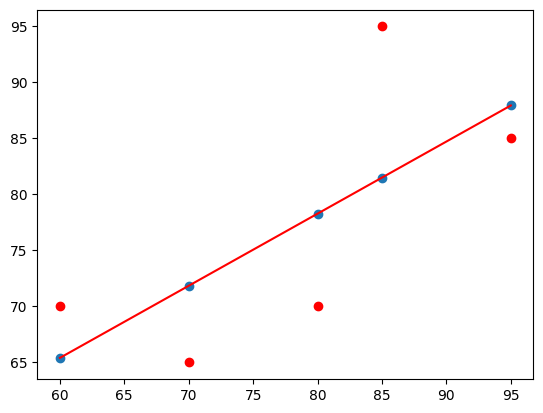

In [144]:
y_line=model[1]+model[0]*x
plt.plot(x, y_line, c='r') 
plt.scatter(x,y_pred)
plt.scatter(x,y,c='r')
plt.show()
# Calculate regression line, plot regression line, plot predicted points, plot actual points, and display graph

In [145]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()
data=pd.DataFrame(housing.data)
data.columns=housing.feature_names
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [146]:
data['PRICE']=housing.target
data.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64

In [147]:
x=data.drop(['PRICE'],axis=1)
y=data['PRICE']

In [148]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)


In [149]:
import sklearn
from sklearn.linear_model import LinearRegression
lm=LinearRegression()

In [150]:
model=lm.fit(x_train,y_train) # Train the linear regression model using training data

In [151]:
y_train_pred = lm.predict(x_train)   # Predict output values for training data
y_test_pred = lm.predict(x_test)     # Predict output values for testing data


In [152]:
df=pd.DataFrame(y_train_pred,y_train)
df=pd.DataFrame(y_test_pred,y_test)

In [153]:
from sklearn.metrics import mean_squared_error,r2_score

In [154]:
mse= mean_squared_error(y_test,y_test_pred)
print(mse)

0.5289841670367225


In [155]:
r2 = r2_score(y_test, y_test_pred)   # Calculate R² score to measure model accuracy
print(r2)                            # Display the R² score

0.594323265246619


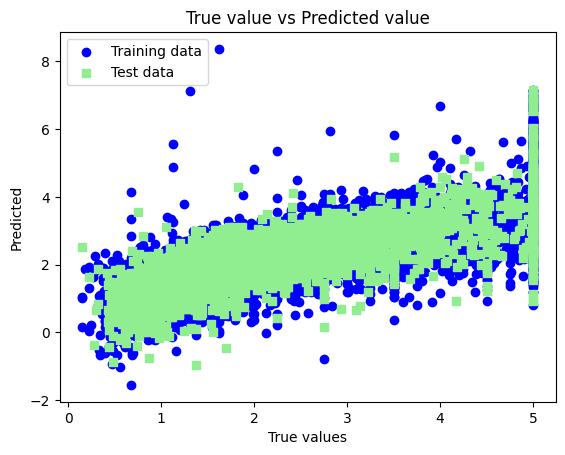

In [156]:
plt.scatter(y_train ,y_train_pred,c='blue',marker='o',label='Training data')
plt.scatter(y_test,y_test_pred ,c='lightgreen',marker='s',label='Test data')
plt.xlabel('True values')
plt.ylabel('Predicted')
plt.title("True value vs Predicted value")
plt.legend(loc= 'upper left')
#plt.hlines(y=0,xmin=0,xmax=50)
plt.plot()
plt.show()